<a href="https://colab.research.google.com/github/Rahulbaid0404/Crop-management-system-for-small-farms/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.tail(11)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
189,190,Female,36,103,85
190,191,Female,34,103,23
191,192,Female,32,103,69
192,193,Male,33,113,8
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.size

1000

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(200, 5)

In [ ]:
df.max()

,0
CustomerID,200
Gender,Male
Age,70
Annual Income (k$),137
Spending Score (1-100),99


In [ ]:
df.mean(numeric_only=True)

,0
CustomerID,100.50
Age,38.85
Annual Income (k$),60.56
Spending Score (1-100),50.20


In [ ]:
df.median(numeric_only=True)

,0
CustomerID,100.5
Age,36.0
Annual Income (k$),61.5
Spending Score (1-100),50.0


In [ ]:
df.mode(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,32.0,54.0,42.0
1,2,NaN,78.0,NaN
2,3,NaN,NaN,NaN
3,4,NaN,NaN,NaN
4,5,NaN,NaN,NaN
...,...,...,...,...
195,196,NaN,NaN,NaN
196,197,NaN,NaN,NaN
197,198,NaN,NaN,NaN
198,199,NaN,NaN,NaN


In [ ]:
df.var(numeric_only=True)

,0
CustomerID,3350.000000
Age,195.133166
Annual Income (k$),689.835578
Spending Score (1-100),666.854271


In [ ]:
df.std(numeric_only=True)

,0
CustomerID,57.879185
Age,13.969007
Annual Income (k$),26.264721
Spending Score (1-100),25.823522


In [ ]:
#Kurtosis measures the “tailedness” or shape of the data distribution.
#It tells how peaked or flat the data distribution is compared to a normal distribution.

df.kurt(numeric_only=True)

,0
CustomerID,-1.200000
Age,-0.671573
Annual Income (k$),-0.098487
Spending Score (1-100),-0.826629


In [ ]:
df.skew(numeric_only=True)

,0
CustomerID,0.000000
Age,0.485569
Annual Income (k$),0.321843
Spending Score (1-100),-0.047220


In [ ]:
# Perform one-hot encoding on the 'Gender' column
df_encoded = pd.get_dummies(df, columns=['Gender'], prefix='encoded')

# Display the first 5 rows of the new encoded dataframe to verify the transformation
print("Original DataFrame:")
print(df.head())
print("\nDataFrame after One-Hot Encoding:")
print(df_encoded.head())

# Print the columns to show the new one-hot encoded columns
print("\nColumns of the encoded DataFrame:")
print(df_encoded.columns)

Original DataFrame:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

DataFrame after One-Hot Encoding:
   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1   19                  15                      39   
1           2   21                  15                      81   
2           3   20                  16                       6   
3           4   23                  16                      77   
4           5   31                  17                      40   

   encoded_Female  encoded_Male  
0           False          True  
1           False          True  
2            True   

In [ ]:
# In short: df.to_numpy() = convert structured table → raw numerical matrix
df.to_numpy()

array([[4.58989e+05, 0.00000e+00, 1.00000e+00, ..., 2.00000e+00,
        1.00000e+00, 5.00000e+00],
       [4.58994e+05, 1.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        4.00000e+00, 5.00000e+00],
       [4.58996e+05, 0.00000e+00, 1.00000e+00, ..., 2.00000e+00,
        1.00000e+00, 5.00000e+00],
       ...,
       [4.67960e+05, 0.00000e+00, 0.00000e+00, ..., 2.00000e+00,
        2.00000e+00, 5.00000e+00],
       [4.67961e+05, 1.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        5.00000e+00, 3.00000e+00],
       [4.67968e+05, 0.00000e+00, 0.00000e+00, ..., 2.00000e+00,
        3.00000e+00, 6.00000e+00]])

In [ ]:
#cumsum() in pandas calculates the cumulative sum of values in each column of the DataFrame.
df.cumsum()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,3,MaleMale,40,30,120
2,6,MaleMaleFemale,60,46,126
3,10,MaleMaleFemaleFemale,83,62,203
4,15,MaleMaleFemaleFemaleFemale,114,79,243
...,...,...,...,...,...
195,19306,MaleMaleFemaleFemaleFemaleFemaleFemaleFemaleMa...,7631,11586,9837
196,19503,MaleMaleFemaleFemaleFemaleFemaleFemaleFemaleMa...,7676,11712,9865
197,19701,MaleMaleFemaleFemaleFemaleFemaleFemaleFemaleMa...,7708,11838,9939
198,19900,MaleMaleFemaleFemaleFemaleFemaleFemaleFemaleMa...,7740,11975,9957


##DATA PREPROCESSING

In [ ]:
df.isnull()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


##Handling Duplicate Values

In [ ]:
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0


In [ ]:
#.unique() is a Pandas function that returns all distinct values in a column.
#It removes duplicates.
#Identify categorical values (like Gender)
#Useful for data cleaning & preprocessing
print(df['CustomerID'].unique())
print(df['Age'].unique())
print(df['Gender'].unique())
print(df['Annual Income (k$)'].unique())
print(df['Spending Score (1-100)'].unique())

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200]
[19 21 20 23 31 22 35 64 30 67 58 24 37 52 25 46 54 29 45 40 60 53 18 49
 42 36 65 48 50 27 33 59 47 51 69 70 63 43 68 32 26 57 38 55 34 66 39 44
 28 56 41]
['Male' 'Female']
[ 15  16  17

In [ ]:
X=df.iloc[:,[3,4]].values

In [ ]:
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Select only object type columns for encoding
categorical_cols = df.select_dtypes(include='object').columns

# Apply LabelEncoder to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("DataFrame after categorical encoding:")
df.info()
display(df.head())


DataFrame after categorical encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


##Finding the parameter WCSS (Within Cluster Sum Of Squares)

It is also known as elbow method and can be visualised using a elbow graph

In [ ]:
#finding wcss for different number of clusters

#WCSS (inertia_):
#Measures how compact the clusters are
#Lower value = better clustering (points are closer to centroid)

wcss=[]

for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

print("WCSS values:", wcss)


WCSS values: [269981.28000000014, 183653.3289473683, 106348.37306211119, 73880.64496247198, 44448.45544793369, 40825.16946386947, 33642.57922077922, 26686.837785187785, 24766.471609793436, 23103.122085983905]


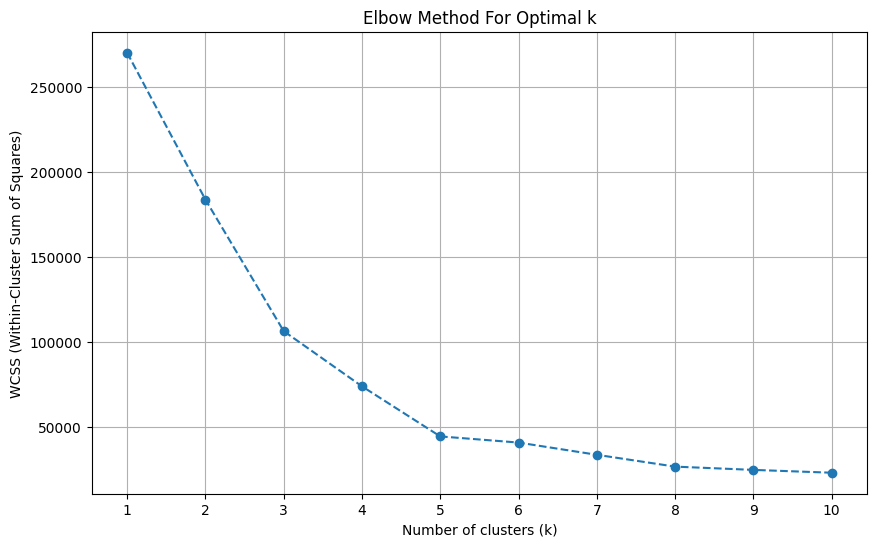

In [ ]:
import matplotlib.pyplot as plt

# Plot the WCSS values to visualize the Elbow Method
#It helps you visually determine the optimal number of clusters (K).
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()
#The most optimum number of clusters in below graph is 5 , as there is no significant drop after that cluster

##Training The K-means Clustering Model

In [ ]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=0)
#return a label for each data point based on their cluster

Y= kmeans.fit_predict(X)
print(Y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


##Visualising each cluster values

Total 5 Clusters: (0,1,2,3,4)

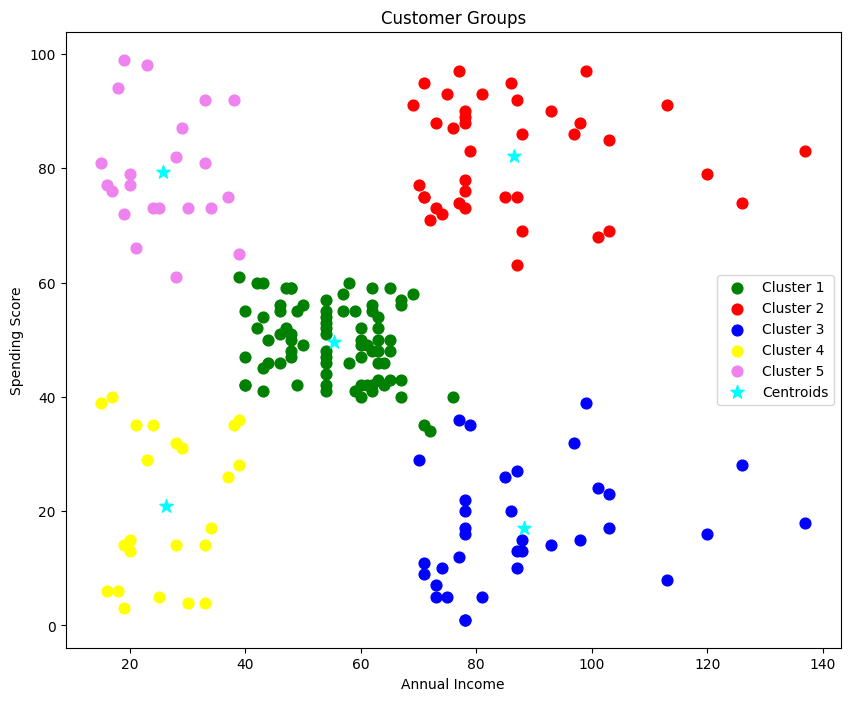

In [ ]:
# plotting the optimum number of clusters and their centroids

plt.figure(figsize=(10,8))
plt.scatter(X[Y==0,0],X[Y==0,1],s =60,c='green',label='Cluster 1')
plt.scatter(X[Y==1,0],X[Y==1,1],s =60,c='red',label='Cluster 2')
plt.scatter(X[Y==2,0],X[Y==2,1],s =60,c='blue',label='Cluster 3')
plt.scatter(X[Y==3,0],X[Y==3,1],s =60,c='yellow',label='Cluster 4')
plt.scatter(X[Y==4,0],X[Y==4,1],s =60,c='violet',label='Cluster 5')

#Plotting the centroids
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],marker='*',s=100,c='cyan',label='Centroids')

plt.title("Customer Groups")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()


##DIMENSIONALITY REDUCTION TECHNIQUES

# Task
Select relevant numerical features ('Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)') from the DataFrame, scale them using `StandardScaler`, and then apply both Principal Component Analysis (PCA) and t-Distributed Stochastic Neighbor Embedding (t-SNE) to reduce the dimensionality to 2 components. Finally, visualize the results of both PCA and t-SNE, coloring the points by the previously identified K-Means clusters (Y), and provide a summary of the insights gained from these visualizations regarding customer group separation in the reduced dimensional spaces.

## Select Features for Dimensionality Reduction

### Subtask:
Select the relevant numerical features ('Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)') from the DataFrame for dimensionality reduction. The 'CustomerID' column will be excluded as it is an identifier and not a feature.


In [ ]:
features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
print("Selected features for dimensionality reduction:")
display(features.head())

Selected features for dimensionality reduction:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## Feature Scaling Using Standardscaler

Scale the selected numerical features (`features`) using `StandardScaler` to standardize them. This step is crucial before applying dimensionality reduction techniques like PCA and t-SNE, as these algorithms are sensitive to the scale of the input features.

#### Instructions:
Initialize a `StandardScaler` object, fit it to the `features` DataFrame, and then transform the `features` data. Store the scaled data in a new variable, for example, `scaled_features`.

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Ensure 'Gender' is encoded if it hasn't been already
# This step is critical as StandardScaler expects numerical input
if 'Gender' in df.columns and df['Gender'].dtype == 'object':
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])

# Re-select features after ensuring 'Gender' is numerical
features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
scaled_features = scaler.fit_transform(features)

print("Scaled features:")
print(scaled_features[:5]) # Display first 5 rows of scaled features

Scaled features:
[[ 1.12815215 -1.42456879 -1.73899919 -0.43480148]
 [ 1.12815215 -1.28103541 -1.73899919  1.19570407]
 [-0.88640526 -1.3528021  -1.70082976 -1.71591298]
 [-0.88640526 -1.13750203 -1.70082976  1.04041783]
 [-0.88640526 -0.56336851 -1.66266033 -0.39597992]]


In [ ]:
#Applying minmax Scalar for perfoerming normalisation
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Ensure 'Gender' is encoded if it hasn't been already
# This step is critical as MinMaxScaler expects numerical input
if 'Gender' in df.columns and df['Gender'].dtype == 'object':
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])

# Re-select features to ensure it's defined and up-to-date
features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Initialize MinMaxScaler
minmax_scaler = MinMaxScaler()

# Fit and transform the features
minmax_scaled_features = minmax_scaler.fit_transform(features)

print("MinMax Scaled features:")
print(minmax_scaled_features[:8])

MinMax Scaled features:
[[1.         0.01923077 0.         0.3877551 ]
 [1.         0.05769231 0.         0.81632653]
 [0.         0.03846154 0.00819672 0.05102041]
 [0.         0.09615385 0.00819672 0.7755102 ]
 [0.         0.25       0.01639344 0.39795918]
 [0.         0.07692308 0.01639344 0.76530612]
 [0.         0.32692308 0.02459016 0.05102041]
 [0.         0.09615385 0.02459016 0.94897959]]


## Apply Principal Component Analysis (PCA)

### Subtask:
Apply Principal Component Analysis (PCA) to the `scaled_features` to reduce their dimensionality to 2 components. PCA is a linear dimensionality reduction technique that aims to capture the most variance in the data.

#### Instructions:
Initialize a `PCA` object with `n_components=2`, fit it to the `scaled_features`, and transform the data. Store the result in a new variable, for example, `pca_features`.

Now that the features are scaled, I will apply PCA to reduce the dimensionality to 2 components, as specified in the subtask. This involves importing PCA, initializing it with 2 components, and then fitting and transforming the `scaled_features`.



In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA with 2 components
pca = PCA(n_components=2)

# Fit and transform the scaled features
pca_features = pca.fit_transform(scaled_features)

print("Shape of PCA-transformed features:", pca_features.shape)
print("First 5 rows of PCA-transformed features:\n", pca_features[:5])

Shape of PCA-transformed features: (200, 2)
First 5 rows of PCA-transformed features:
 [[-0.40638272 -0.52071363]
 [-1.42767287 -0.3673102 ]
 [ 0.05076057 -1.89406774]
 [-1.6945131  -1.63190805]
 [-0.31310838 -1.81048272]]


## Apply t-Distributed Stochastic Neighbor Embedding (t-SNE)

### Subtask:
Apply t-Distributed Stochastic Neighbor Embedding (t-SNE) to the `scaled_features` to reduce their dimensionality to 2 components. t-SNE is a non-linear dimensionality reduction technique well-suited for visualizing high-dimensional datasets.

#### Instructions:
Initialize a `TSNE` object with `n_components=2`, fit it to the `scaled_features`, and transform the data. Store the result in a new variable, for example, `tsne_features`. Consider setting `random_state` for reproducibility and `perplexity` as it's a crucial parameter for t-SNE.


Now that the markdown block for t-SNE has been presented, the next step is to implement the t-SNE dimensionality reduction. This involves importing the `TSNE` class, initializing it with `n_components=2` and a `random_state` for reproducibility, and then fitting and transforming the `scaled_features`.



In [ ]:
from sklearn.manifold import TSNE
#This code reduces high-dimensional scaled data into 2 dimensions using t-SNE for visualization and prints the transformed dataset.
# Initialize t-SNE with 2 components
# Set random_state for reproducibility and perplexity (common values are between 5 and 50)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Fit and transform the scaled features
tsne_features = tsne.fit_transform(scaled_features)

print("Shape of t-SNE transformed features:", tsne_features.shape)
print("First 5 rows of t-SNE transformed features:\n", tsne_features[:5])

Shape of t-SNE transformed features: (200, 2)
First 5 rows of t-SNE transformed features:
 [[ 2.4259703 -7.152119 ]
 [ 3.0424936 -5.47838  ]
 [-4.405653  14.091286 ]
 [-7.8193455 12.497788 ]
 [-4.6307945 12.384195 ]]


## Visualize PCA and t-SNE Results with K-Means Clusters

### Subtask:
Visualize the results of both PCA (`pca_features`) and t-SNE (`tsne_features`), coloring the points by the previously identified K-Means clusters (`Y`). Provide a summary of the insights gained from these visualizations regarding customer group separation in the reduced dimensional spaces.

#### Instructions:
1. Create two separate scatter plots: one for PCA-transformed features and one for t-SNE transformed features.
2. In both plots, use the `Y` array (K-Means cluster labels) to color the data points.
3. Add appropriate titles, axis labels, and legends to each plot.
4. After visualizing, provide a written summary of the observations.

**Reasoning**:
To visualize the PCA-transformed features, I will create a scatter plot. Each point will be colored according to its K-Means cluster assignment (stored in `Y`), allowing for an examination of how well the clusters are separated in the PCA-reduced space. This is the first visualization requested in the subtask.



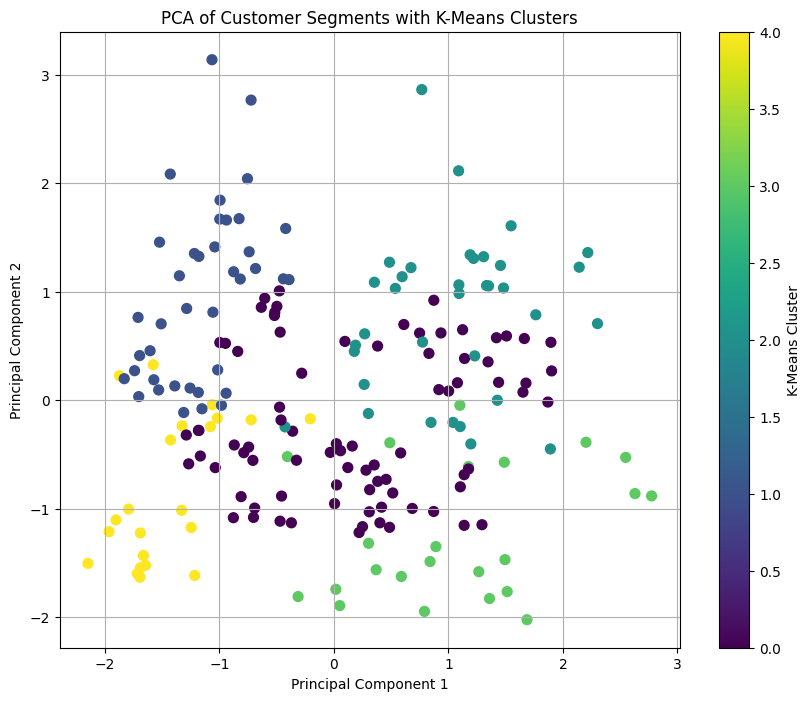

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Re-define K-Means model and predict clusters for X
# X was previously defined as df.iloc[:,[3,4]].values
# kmeans model was previously defined with n_clusters=5


kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0, n_init=10)
# Added n_init for modern sklearn versions

# Re-define X here to ensure it's available
X = df.iloc[:,[3,4]].values

# Predict the clusters for X
Y = kmeans.fit_predict(X)

plt.figure(figsize=(10, 8))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=Y, cmap='viridis', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Customer Segments with K-Means Clusters')
plt.colorbar(label='K-Means Cluster')
plt.grid(True)
plt.show()

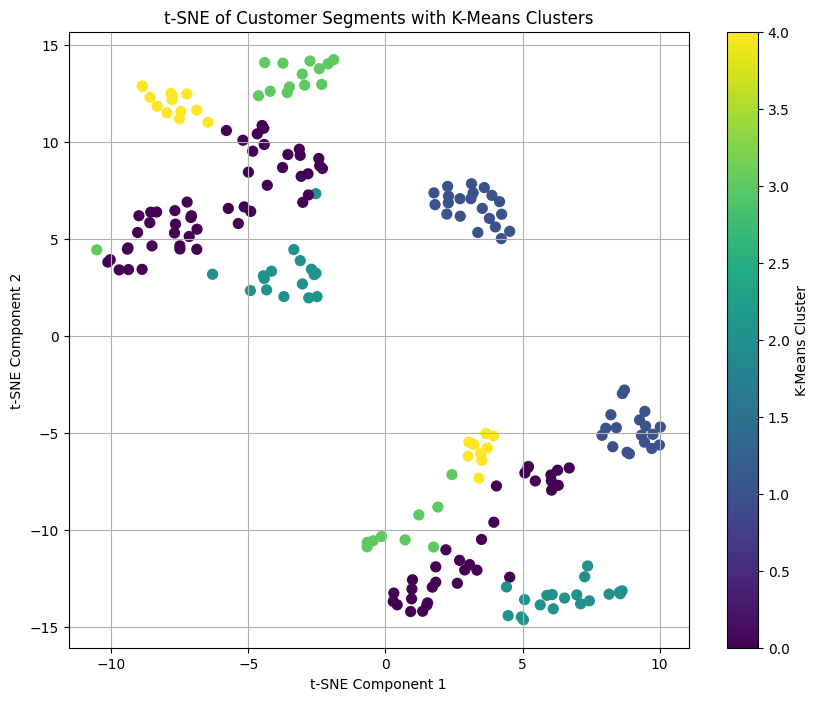

In [ ]:
#This code plots customer clusters in a 2D space using t-SNE dimensionality reduction and colors them according to K-Means cluster labels.
plt.figure(figsize=(10, 8))
plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=Y, cmap='viridis', s=50)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of Customer Segments with K-Means Clusters')
plt.colorbar(label='K-Means Cluster')
plt.grid(True)
plt.show()

## Summary of Insights from PCA and t-SNE Visualizations

**PCA Visualization:**
The PCA plot shows some separation among the K-Means clusters, particularly distinguishing between the high annual income/high spending score group (often seen as a distinct cluster) and the low annual income/low spending score group. However, other clusters tend to overlap more, indicating that a linear dimensionality reduction method like PCA might not fully capture the complex, non-linear relationships that define some of the customer segments. The clusters are generally spread out, but their boundaries are not always clear, suggesting that the primary components might not perfectly align with the cluster structures defined by K-Means based on the original features.

**t-SNE Visualization:**
The t-SNE plot generally presents a much clearer separation of the K-Means clusters compared to PCA. This is expected, as t-SNE is designed to preserve local neighborhood structures in high-dimensional data, making it very effective for visualizing clusters. We can observe more distinct, compact groupings for each cluster, with less overlap between them. This suggests that the K-Means algorithm effectively identified meaningful customer segments in the original feature space, and t-SNE has done a better job of representing these distinct groups in a 2D space for visualization. The separation implies that these customer segments have strong internal coherence and are well-differentiated from each other based on their combined 'Gender', 'Age', 'Annual Income (k$)', and 'Spending Score (1-100)' characteristics.

**Overall Conclusion:**
While PCA provides a general sense of data structure, t-SNE offers a superior visualization for understanding the distinctiveness and boundaries of the K-Means clusters. The t-SNE plot effectively demonstrates that the 5 K-Means clusters represent well-separated customer segments, which can be highly valuable for targeted marketing strategies or customer relationship management.

# Task
The next step is to generate a dendrogram to visualize the hierarchical clustering process. This will help in determining the optimal number of clusters for the dataset.

I will start by calculating the linkage matrix using `scipy.cluster.hierarchy.linkage` on the prepared data `X`. Then, I will plot a dendrogram using `scipy.cluster.hierarchy.dendrogram`. This visualization will show how the data points are merged into clusters and will be crucial for identifying natural groupings.

## Prepare Data for Clustering

### Subtask:
Select the 'Annual Income (k$)' and 'Spending Score (1-100)' columns from the DataFrame `df` and store them in a variable `X`. This will be the dataset used for hierarchical clustering.


## Generate Dendrogram

### Subtask:
Calculate the linkage matrix using `scipy.cluster.hierarchy.linkage` on the prepared data `X`. Then, plot a dendrogram using `scipy.cluster.hierarchy.dendrogram` to visualize the hierarchical clustering process and determine the optimal number of clusters. The dendrogram will be crucial for identifying natural groupings in the data.


**Reasoning**:
To generate a dendrogram, I will first import the necessary functions from `scipy.cluster.hierarchy`. Then, I'll calculate the linkage matrix using the `X` data and the 'ward' method, and finally plot the dendrogram as specified in the instructions.



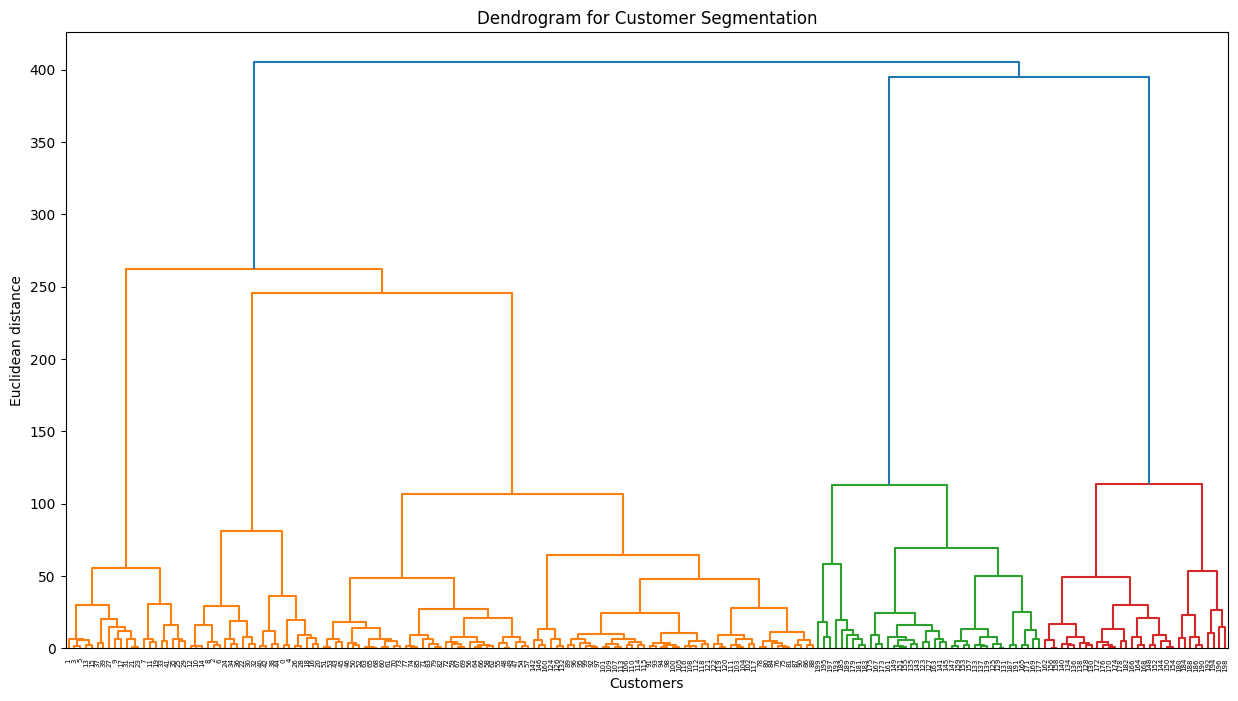

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataframe as it was not defined in the current scope
df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')

# Re-define X as specified for hierarchical clustering
X = df.iloc[:,[3,4]].values

# Calculate the linkage matrix
merges = sch.linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
sch.dendrogram(merges)
plt.title('Dendrogram for Customer Segmentation')
plt.xlabel('Customers')
plt.ylabel('Euclidean distance')
plt.show()

## Apply Hierarchical Clustering

### Subtask:
Based on the insights from the dendrogram, apply `AgglomerativeClustering` from `sklearn.cluster` to the data `X`. The number of clusters will be chosen from the dendrogram. Assign the resulting cluster labels to a new variable.


**Reasoning**:
To apply hierarchical clustering, I will import `AgglomerativeClustering`, initialize it with the number of clusters determined from the dendrogram (5 in this case, for consistency with K-Means), and then fit and predict the cluster labels on the `X` data.



In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Based on the dendrogram, let's choose 5 clusters for demonstration.
# In a real scenario, you would visually inspect the dendrogram for the optimal number.
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')

# Fit the model to the data and predict the cluster labels
h_clusters = hc.fit_predict(X)

print("Hierarchical Cluster Labels:")
print(h_clusters)

Hierarchical Cluster Labels:
[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


## Visualize Hierarchical Clusters

### Subtask:
Create a scatter plot of the data points, coloring them according to their assigned hierarchical cluster labels. The x-axis will represent 'Annual Income (k$)' and the y-axis will represent 'Spending Score (1-100)'. This visualization will show how well the hierarchical clustering algorithm separated the customer segments. Ensure to include a legend for the clusters and appropriate labels for the axes and title.


**Reasoning**:
I will generate a code block to create a scatter plot of the hierarchical clusters, as specified in the instructions. This involves iterating through each cluster, plotting its points with distinct colors, and adding a title, axis labels, and a legend to the plot.



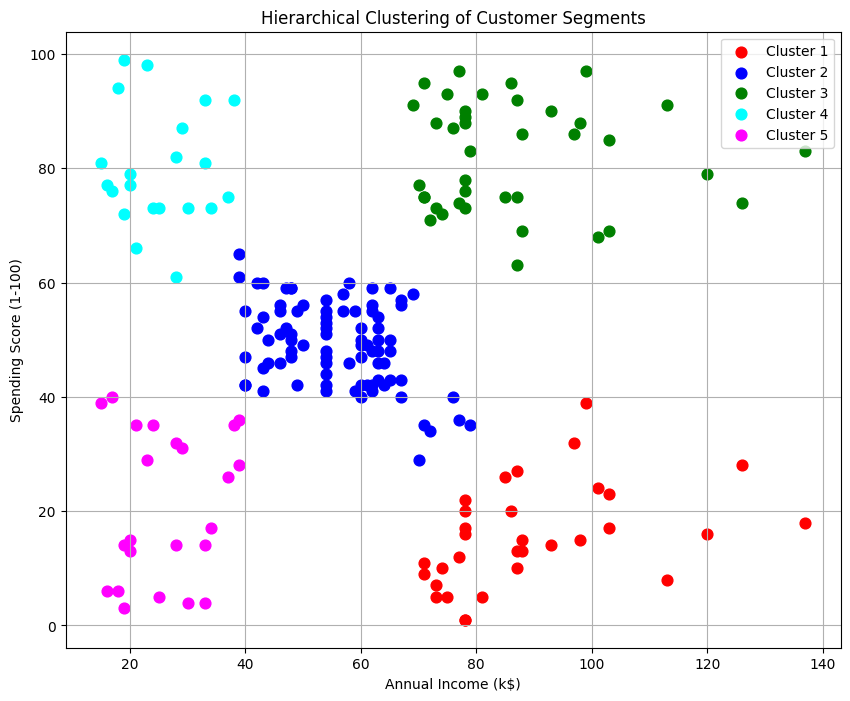

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming X contains 'Annual Income (k$)' and 'Spending Score (1-100)'
# and h_clusters contains the hierarchical cluster labels (0 to 4 for 5 clusters)

plt.figure(figsize=(10, 8))

# Define colors for the 5 clusters
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

# Plot each cluster
for i in range(5):
    plt.scatter(X[h_clusters == i, 0], X[h_clusters == i, 1],
                s = 60, c = colors[i], label = labels[i])

plt.title('Hierarchical Clustering of Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()